In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
import os

tickers = [
    "AAPL", "MSFT", "GOOGL", "META", "AMZN", "NFLX", "TSLA", "ABNB",
    "NVDA", "AMD", "INTC", "QCOM", "AVGO", "MU", "ARM", "AMAT",
    "V", "MA", "PYPL", "COIN", "HOOD",
    "JPM", "GS", "BAC", "WFC", "MS", "BLK",
    "CRM", "NOW", "SNOW", "PLTR", "NET", "DDOG", "MDB",
    "WMT", "TGT", "COST", "EBAY", "SHOP",
    "UNH", "ISRG", "DXCM",
    "ENPH", "FSLR", "RIVN"
]
os.makedirs("data/features", exist_ok=True)

In [2]:
def add_features(ticker):
    df = pd.read_csv(f"data/raw/{ticker}_price.csv", index_col=0)
    df.index = pd.to_datetime(df.index)
    df = df.dropna().sort_index()

    close = df["Close"]
    high = df["High"]
    low = df["Low"]
    volume = df["Volume"]

    df["SMA_20"] = ta.trend.sma_indicator(close, window=20)
    df["SMA_50"] = ta.trend.sma_indicator(close, window=50)
    df["EMA_20"] = ta.trend.ema_indicator(close, window=20)

    df["RSI_14"] = ta.momentum.rsi(close, window=14)

    macd = ta.trend.MACD(close)
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()
    df["MACD_diff"] = macd.macd_diff()

    bb = ta.volatility.BollingerBands(close, window=20)
    df["BB_upper"] = bb.bollinger_hband()
    df["BB_lower"] = bb.bollinger_lband()
    df["BB_width"] = bb.bollinger_wband()

    df["Volatility_20"] = close.pct_change().rolling(20).std()

    df["Return_1d"] = close.pct_change(1)
    df["Return_3d"] = close.pct_change(3)
    df["Return_5d"] = close.pct_change(5)

    df["Target"] = (close.shift(-1) > close).astype(int)

    df = df.dropna()

    df.to_csv(f"data/features/{ticker}_features.csv")
    print(f"{ticker}: {len(df)} 行，{len(df.columns)} 列特征")
    return df

for ticker in tickers:
    add_features(ticker)

AAPL: 1839 行，20 列特征
MSFT: 1839 行，20 列特征
GOOGL: 1839 行，20 列特征
META: 1839 行，20 列特征
AMZN: 1839 行，20 列特征
NFLX: 1839 行，20 列特征
TSLA: 1839 行，20 列特征
ABNB: 1349 行，20 列特征
NVDA: 1839 行，20 列特征
AMD: 1839 行，20 列特征
INTC: 1839 行，20 列特征
QCOM: 1839 行，20 列特征
AVGO: 1839 行，20 列特征
MU: 1839 行，20 列特征
ARM: 656 行，20 列特征
AMAT: 1839 行，20 列特征
V: 1839 行，20 列特征
MA: 1839 行，20 列特征
PYPL: 1839 行，20 列特征
COIN: 1265 行，20 列特征
HOOD: 1191 行，20 列特征
JPM: 1839 行，20 列特征
GS: 1839 行，20 列特征
BAC: 1839 行，20 列特征
WFC: 1839 行，20 列特征
MS: 1839 行，20 列特征
BLK: 1839 行，20 列特征
CRM: 1839 行，20 列特征
NOW: 1839 行，20 列特征
SNOW: 1409 行，20 列特征
PLTR: 1399 行，20 列特征
NET: 1663 行，20 列特征
DDOG: 1659 行，20 列特征
MDB: 1839 行，20 列特征
WMT: 1839 行，20 列特征
TGT: 1839 行，20 列特征
COST: 1839 行，20 列特征
EBAY: 1839 行，20 列特征
SHOP: 1839 行，20 列特征
UNH: 1839 行，20 列特征
ISRG: 1839 行，20 列特征
DXCM: 1839 行，20 列特征
ENPH: 1839 行，20 列特征
FSLR: 1839 行，20 列特征
RIVN: 1118 行，20 列特征


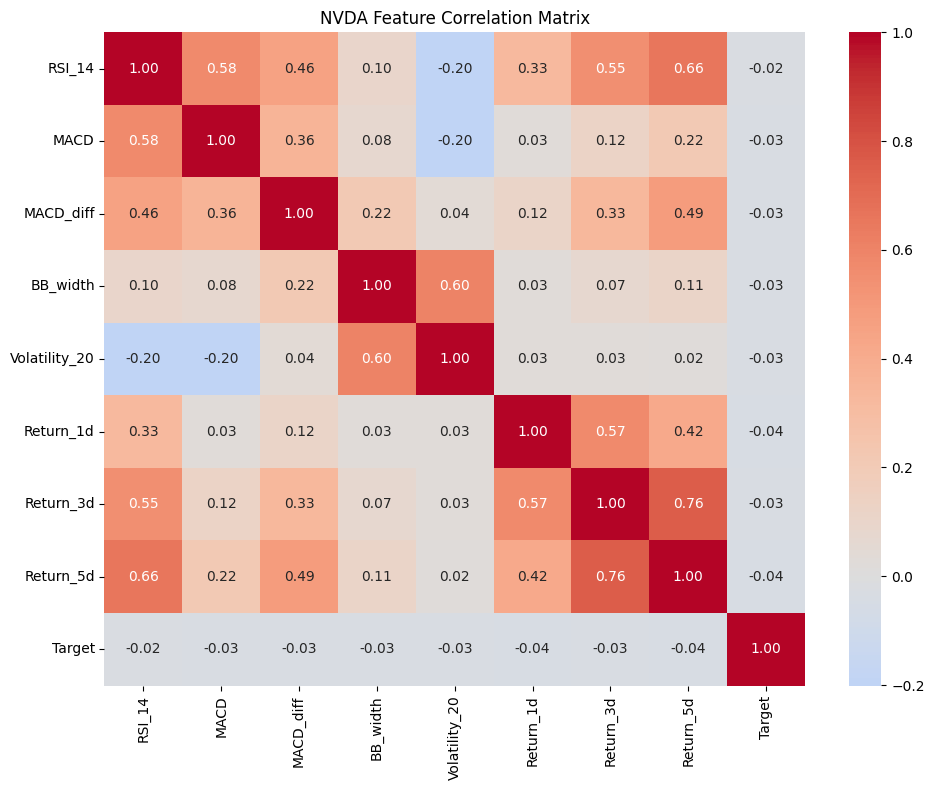

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 用 NVDA 做示例
df = pd.read_csv("data/features/NVDA_features.csv", index_col=0)

feature_cols = ["RSI_14", "MACD", "MACD_diff", "BB_width", 
                "Volatility_20", "Return_1d", "Return_3d", "Return_5d", "Target"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("NVDA Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("data/features/NVDA_correlation.png", dpi=150)
plt.show()

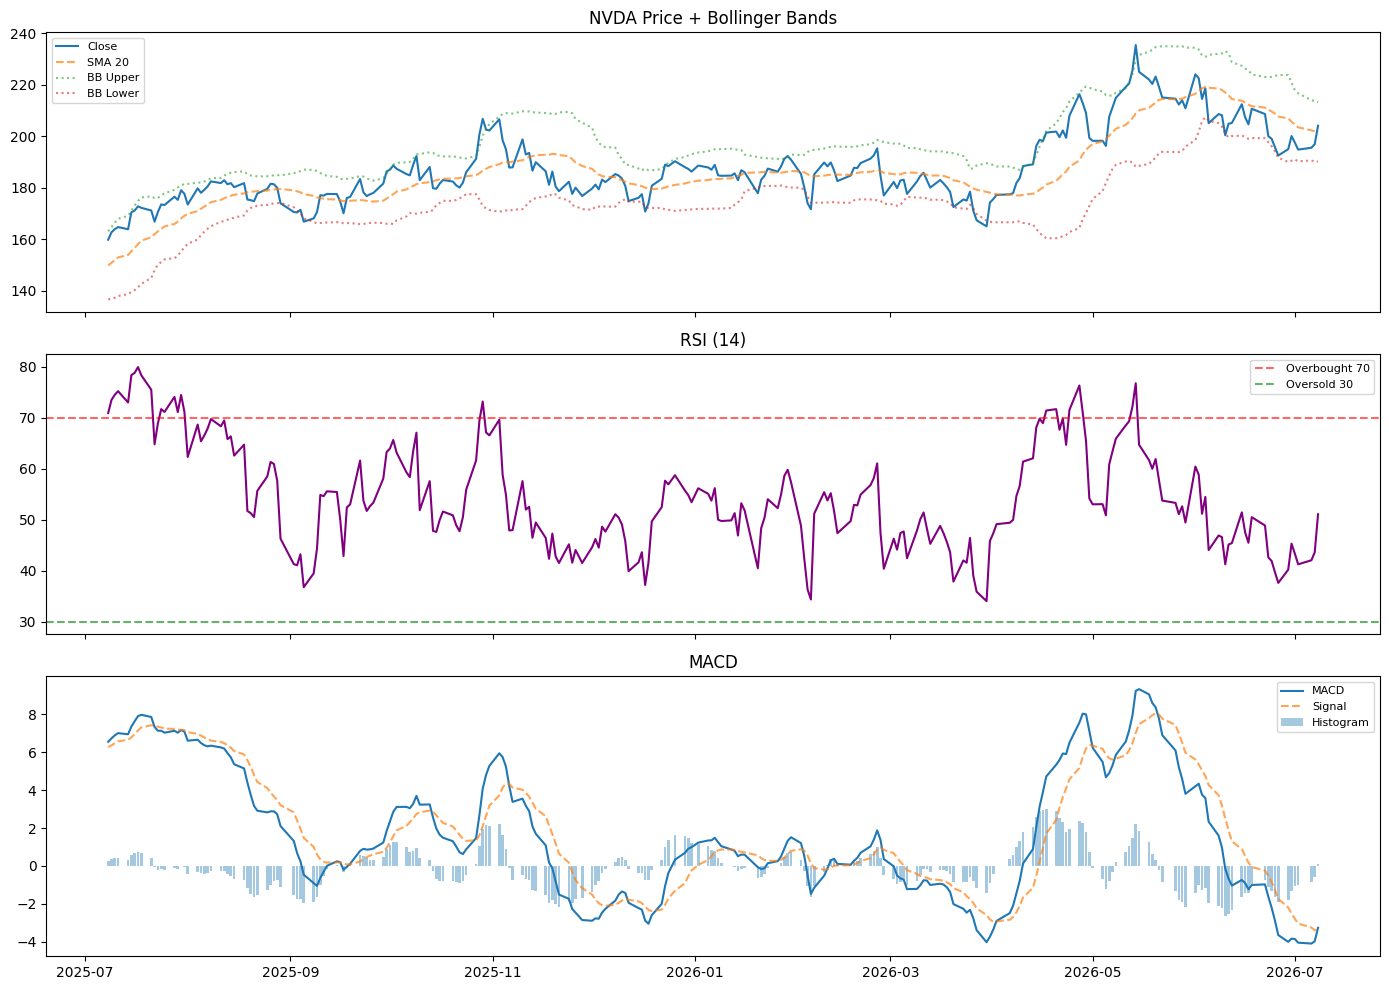

In [4]:
df = pd.read_csv("data/features/NVDA_features.csv", index_col=0, parse_dates=True)
df_plot = df.tail(252)  # 最近一年

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 价格 + 布林带 + SMA
axes[0].plot(df_plot.index, df_plot["Close"], label="Close", linewidth=1.5)
axes[0].plot(df_plot.index, df_plot["SMA_20"], label="SMA 20", linestyle="--", alpha=0.7)
axes[0].plot(df_plot.index, df_plot["BB_upper"], label="BB Upper", linestyle=":", alpha=0.6)
axes[0].plot(df_plot.index, df_plot["BB_lower"], label="BB Lower", linestyle=":", alpha=0.6)
axes[0].set_title("NVDA Price + Bollinger Bands")
axes[0].legend(fontsize=8)

# RSI
axes[1].plot(df_plot.index, df_plot["RSI_14"], color="purple", linewidth=1.5)
axes[1].axhline(70, color="red", linestyle="--", alpha=0.6, label="Overbought 70")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.6, label="Oversold 30")
axes[1].set_title("RSI (14)")
axes[1].legend(fontsize=8)

# MACD
axes[2].plot(df_plot.index, df_plot["MACD"], label="MACD", linewidth=1.5)
axes[2].plot(df_plot.index, df_plot["MACD_signal"], label="Signal", linestyle="--", alpha=0.7)
axes[2].bar(df_plot.index, df_plot["MACD_diff"], label="Histogram", alpha=0.4)
axes[2].set_title("MACD")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("data/features/NVDA_indicators.png", dpi=150)
plt.show()

In [5]:
print("=== Week 3 特征工程报告 ===")
for ticker in tickers:
    df = pd.read_csv(f"data/features/{ticker}_features.csv", index_col=0)
    print(f"{ticker}: {len(df)} 行, {len(df.columns)} 列, Target分布: {df['Target'].value_counts().to_dict()}")

=== Week 3 特征工程报告 ===
AAPL: 1839 行, 20 列, Target分布: {1: 983, 0: 856}
MSFT: 1839 行, 20 列, Target分布: {1: 977, 0: 862}
GOOGL: 1839 行, 20 列, Target分布: {1: 990, 0: 849}
META: 1839 行, 20 列, Target分布: {1: 956, 0: 883}
AMZN: 1839 行, 20 列, Target分布: {1: 962, 0: 877}
NFLX: 1839 行, 20 列, Target分布: {1: 934, 0: 905}
TSLA: 1839 行, 20 列, Target分布: {1: 965, 0: 874}
ABNB: 1349 行, 20 列, Target分布: {1: 686, 0: 663}
NVDA: 1839 行, 20 列, Target分布: {1: 995, 0: 844}
AMD: 1839 行, 20 列, Target分布: {1: 938, 0: 901}
INTC: 1839 行, 20 列, Target分布: {0: 920, 1: 919}
QCOM: 1839 行, 20 列, Target分布: {1: 955, 0: 884}
AVGO: 1839 行, 20 列, Target分布: {1: 982, 0: 857}
MU: 1839 行, 20 列, Target分布: {1: 963, 0: 876}
ARM: 656 行, 20 列, Target分布: {1: 343, 0: 313}
AMAT: 1839 行, 20 列, Target分布: {1: 976, 0: 863}
V: 1839 行, 20 列, Target分布: {1: 991, 0: 848}
MA: 1839 行, 20 列, Target分布: {1: 983, 0: 856}
PYPL: 1839 行, 20 列, Target分布: {1: 946, 0: 893}
COIN: 1265 行, 20 列, Target分布: {0: 670, 1: 595}
HOOD: 1191 行, 20 列, Target分布: {1: 604, 0: 587}
